### CNN 전이 학습

In [1]:
import os
import time
import copy
import glob
import cv2 # Open CV 라이브러리
import shutil
import warnings

import torch
import torchvision # 컴퓨터 비전 용도의 패키지
import torchvision.transforms as transforms # 데이터 전처리 패키지
import torchvision.models as models # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

**이미지 데이터 전처리 방법 정의**

In [2]:
os.getcwd()

'/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4'

In [3]:
data_path = 'chap05/data/catanddog/train'
data_path = os.path.join(os.getcwd(), data_path)

transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)
train_dataset = torchvision.datasets.ImageFolder(
    data_path, 
    transform = transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 32, num_workers = 8, shuffle = True
)

print(len(train_dataset))

385


**학습에 사용될 이미지 출력**

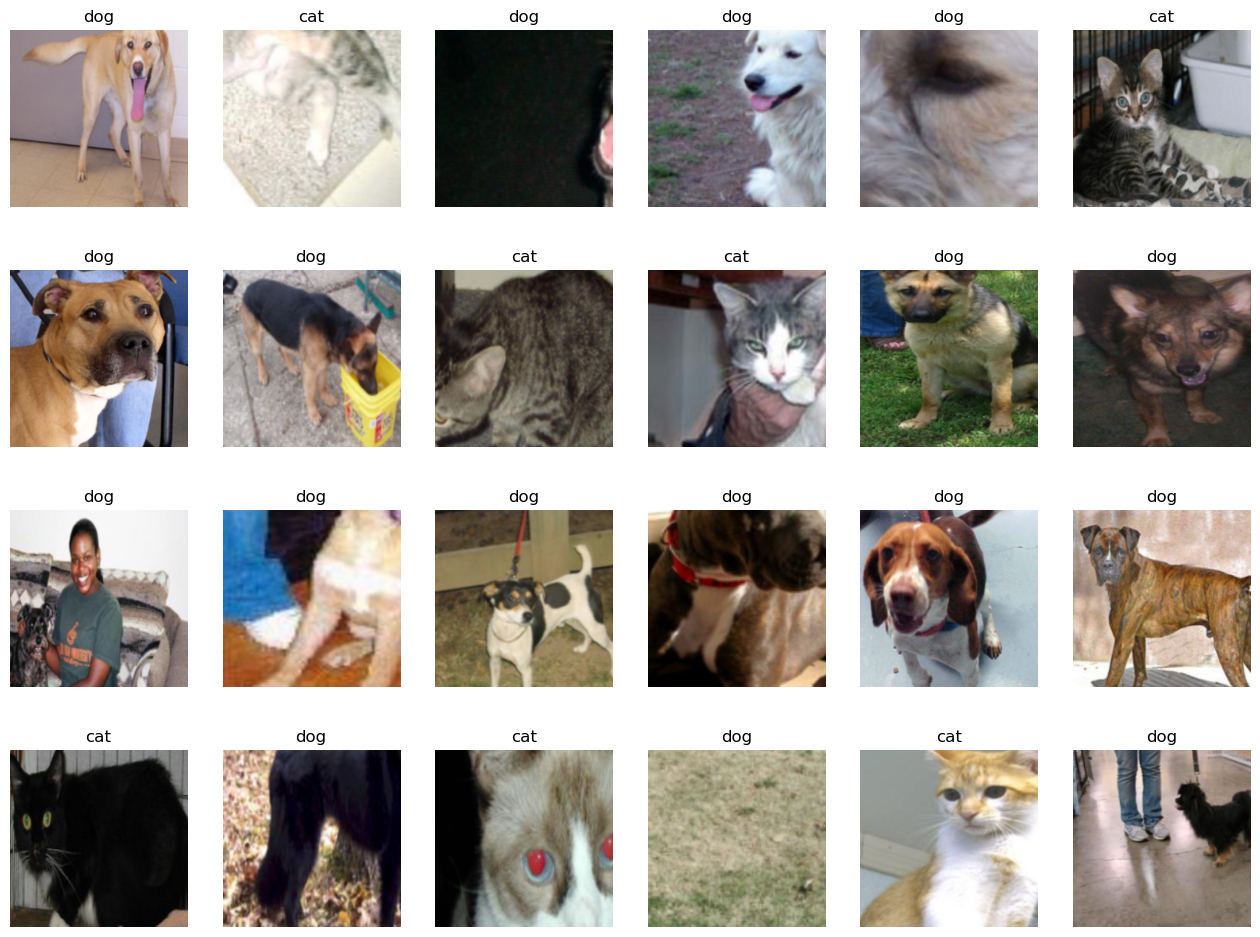

In [4]:
samples, labels = next(iter(train_loader)) #
classes = {0: 'cat', 1: 'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize = (16, 24))
for i in range(24): # 24 개의 이미지 데이터 출력 
    a = fig.add_subplot(4, 6, i + 1)
    a.set_title(classes[labels[i].item()]) # 레이블 정보(클래스)를 함께 출력
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0)))
plt.subplots_adjust(bottom = 0.2, top = 0.6, hspace = 0)

**사전 훈련된 모델 내려받기**

In [5]:
resnet18 = models.resnet18(pretrained = True) # pretrained = True: 사전 학습된 가중치 사용

/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**사전 훈련된 모델의 파라미터 학습 유무 지정**

In [6]:
def set_parameters_requires_grad(model, feature_extracting = True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False # 파라미터 변화 계산 x

set_parameters_requires_grad(resnet18)

**ResNet18에 완전 연결층 추가**

In [7]:
resnet18.fc = nn.Linear(512, 2)

**모델의 파라미터 값 확인**

In [8]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[-0.0305,  0.0028,  0.0223,  ..., -0.0374, -0.0231, -0.0437],
        [-0.0076, -0.0153, -0.0371,  ...,  0.0374, -0.0441,  0.0214]])
fc.bias tensor([-0.0157,  0.0379])


**모델 객체 생성 및 손실 함수 정의**

In [9]:
warnings.filterwarnings(action='ignore')
model = models.resnet18(pretrained = True) # 모델 객체 생성

for param in model.parameters(): 
    param.requires_grad = False # 모델의 합성곱층 가중치 고정

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters():
    param.requires_grad = True # 완전 연결층은 학습

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() # 손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**모델 학습을 위한 함수 생성**

In [10]:
def train_model(model, dataloaders, criterion, optimizer, 
                device, num_epochs = 13, is_train = True):
    since = time.time() # 컴퓨터의 현재 시각
    acc_history = [] # 각 epoch마다 정확도를 저장하는 리스트.
    loss_history = [] # 각 epoch마다 손실 값을 저장하는 리스트.
    best_acc = 0.0 # 지금까지의 최고 정확도를 저장하는 변수.

    for epoch in range(num_epochs): # 에포크(13)만큼 반복
        print("Epoch {}/{}".format(epoch, num_epochs - 1)) # 현재 몇 번째 epoch인지 출력합니다.
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders: # 데이터로더에 전달된 데이터만큼 반복 # dataloaders에서 배치 단위로 데이터를 하나씩 꺼내옵니다.
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad() # 기울기를 0으로 설정 (기울기 초기화)
            outputs = model(inputs) # 순전파 학습
            loss = criterion(outputs, labels) # 손실 함수 계산
            _, preds = torch.max(outputs, 1) # 가장 높은 확률을 가진 클래스 인덱스를 예측 결과로 선택
            loss.backward() # 역전파 수행
            optimizer.step() # 모델의 가중치를 업데이트

            running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
            running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장
        
        epoch_loss = running_loss / len(dataloaders.dataset) # 평균 오차 계산
        epoch_acc = running_corrects.float() / len(dataloaders.dataset) # 평균 정확도 계산

        print(f'Loss: {epoch_loss:.4f} Acc {epoch_acc:.4f}')

        if epoch_acc > best_acc:
            best_acc = epoch_acc # 지금까지 최고 정확도 계산
        
        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join(data_path,
                                                    '{0:0=2d}.pth'.format(epoch))) # 모델 재사용을 위해 저장
        
        print()

    time_elapsed = time.time() - since # 실행 시간 계산
    print('Training complete in {:.0f}m {:0f}s'.format(time_elapsed//60, time_elapsed % 60))
    print('Best Acc: {:.4f}'.format(best_acc))
    return acc_history, loss_history # 모델의 정확도와 오차를 반환

**파라미터 학습 결과를 옵티마이저에 전달**

In [11]:
params_to_update = []
for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param) # 파라미터 학습 결과 저장
        print("\t", name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


**모델 학습**

In [12]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
criterion = nn.CrossEntropyLoss() # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, 
                                              optimizer, device)

Epoch 0/12
----------
Loss: 0.6792 Acc 0.5896

Epoch 1/12
----------
Loss: 0.4151 Acc 0.8312

Epoch 2/12
----------
Loss: 0.3702 Acc 0.8286

Epoch 3/12
----------
Loss: 0.2859 Acc 0.8883

Epoch 4/12
----------
Loss: 0.2541 Acc 0.9117

Epoch 5/12
----------
Loss: 0.2488 Acc 0.9169

Epoch 6/12
----------
Loss: 0.2730 Acc 0.8727

Epoch 7/12
----------
Loss: 0.2170 Acc 0.9221

Epoch 8/12
----------
Loss: 0.2234 Acc 0.9143

Epoch 9/12
----------
Loss: 0.2167 Acc 0.9169

Epoch 10/12
----------
Loss: 0.1805 Acc 0.9403

Epoch 11/12
----------
Loss: 0.1778 Acc 0.9351

Epoch 12/12
----------
Loss: 0.2050 Acc 0.9143

Training complete in 16m 47.972305s
Best Acc: 0.9403


94 %로 상당히 높은 정확도를 보여줌

**테스트 데이터 호출 및 전처리**

In [13]:
test_path =  'chap05/data/catanddog/test'
test_path = os.path.join(os.getcwd(), test_path)

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor()
]
)

test_dataset= torchvision.datasets.ImageFolder(
    root = test_path,
    transform = transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size = 32, num_workers = 1, shuffle = True
)

print(len(test_dataset))

98


**테스트 데이터 평가 함수 생성**

In [14]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('../chap05/data/cantanddog/' + '*.pth')
    saved_models.sort() # 불러온 .pth 파일 정렬
    print('saved_model', saved_models)
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model []


In [15]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob(data_path + '/*.pth')
    saved_models.sort() # 불러온 .pth 파일 정렬
    print('saved_model', saved_models)

    for model_path in saved_models:
        print("Loading model", model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders: # 테스트 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
                outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장
            
            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1
            preds[preds < 0.5] = 0
            running_corrects += preds.eq(labels).int().sum()
        
        epoch_acc = running_corrects.float() / len(dataloaders.dataset) # 테스트 데이터 정확도 계산
        print(f'Acc: {epoch_acc:.4f}')

        if epoch_acc > best_acc:
            best_acc = epoch_acc
        acc_history.append(epoch_acc.item())
        print()
    
    time_elapsed = time.time() - since
    print(f"Validation complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}")
    print(f"Best Acc: {best_acc:.4f}")

    return acc_history # 계산된 정확도 반환

**테스트 데이터를 평가 함수에 적용**

In [16]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/00.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/01.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/02.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/03.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/04.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/05.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/06.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/07.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/08.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/train/09.pth', '/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week4/chap05/data/catanddog/t

테스트 데이터 역시 94 % 정도의 높은 정확도를 보임. 

**훈련과 테스트 데이터의 정확도를 그래프로 확인**

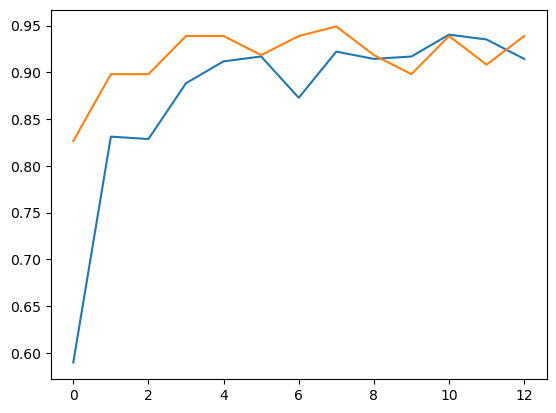

In [17]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

**훈련 데이터의 오차에 대한 그래프 확인**

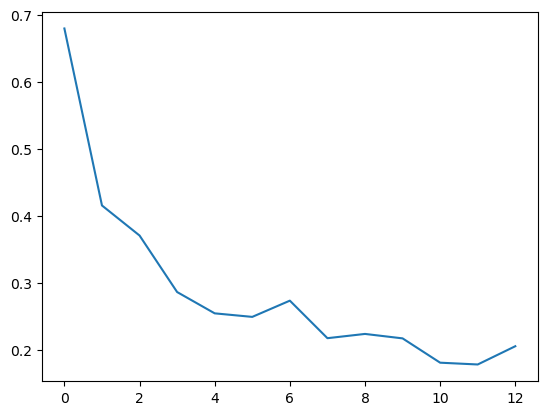

In [18]:
plt.plot(train_loss_hist)
plt.show()

**예측 이미지 출력을 위한 전처리 함수**

In [19]:
def im_convert(tensor):
    image = tensor.clone().detach().numpy()
    image = image.transpose(1, 2, 0)
    image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
    image = image.clip(0, 1)
    return image

**개와 고양이 예측 결과 출력**

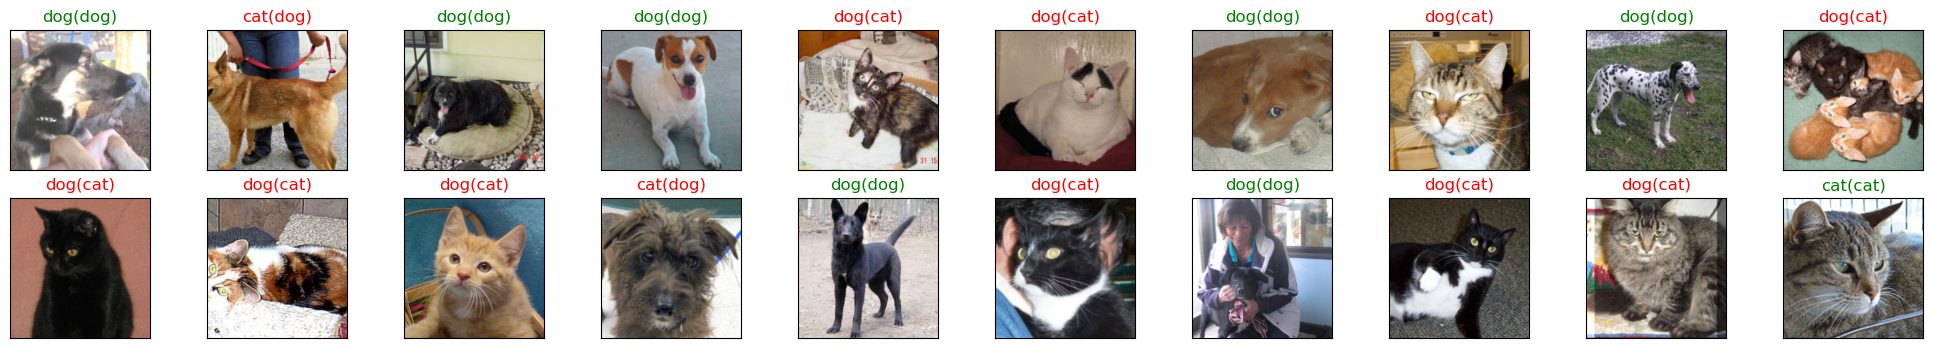

<Figure size 640x480 with 0 Axes>

In [20]:
classes = {0: 'cat', 1: 'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize = (25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks = [], yticks = [])
    plt.imshow(im_convert(images[idx]))
    ax.set_title(classes[labels[idx].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]), 
                            str(classes[labels[idx].item()])), 
                            color = ("green" if preds[idx] == labels[idx] else "red"))

plt.show()
plt.subplots_adjust(bottom = 0.2, top = 0.6, hspace = 0)

### 특성 맵 시각화

In [21]:
import matplotlib.pyplot as plt
import PIL as Image
import cv2
import torch
import torch.nn.functional as F
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

devcie = torch.device('mps' if torch.backends.mps.is_available() else "cpu")
print(device)

mps


**설명 가능한 네트워크 생성**

In [22]:
class XAI(nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),  # inplace=True는 기존의 데이터를 연산의 결과값으로 대체한다는 의미
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        return F.log_softmax(x, dim=1)


**모델 객체화**

In [23]:
model = XAI()
model.to(device)
model.eval()

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

**특성 맵의 결과를 확인할 수 있는 함수 정의**

In [24]:
class LayerActivations:
    features = None 
    def __init__(self, model, layer_num):
        self.hook = model[layer_num].register_forward_hook(self.hook_fn)
    
    def hook_fn(self, module, input, output):
        self.features = output.detach().cpu().numpy()

    def remove(self):
        self.hook.remove()

**이미지 호출**

torch.Size([1, 3, 100, 100])


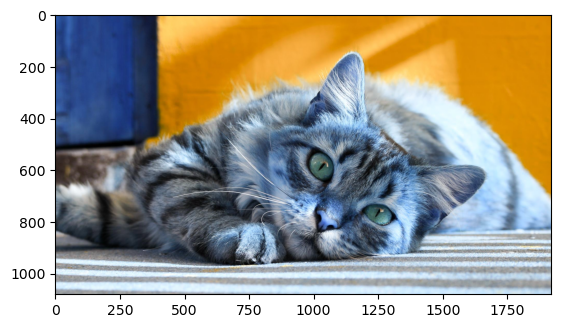

In [25]:
img = cv2.imread('chap05/data/cat.jpg')
plt.imshow(img)
img = cv2.resize(img, (100, 100), interpolation = cv2.INTER_LINEAR)
img = ToTensor()(img).unsqueeze(0) 
img = img.to(device)
print(img.shape)

**Conv2d 특성맵 확인**

In [26]:
result = LayerActivations(model.features, 0) # 0번째 conv2d 특성 맵 확인
model(img).to(device)
activations = result.features

**특성 맵 확인**

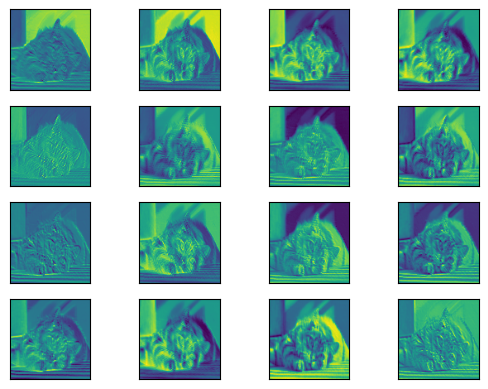

<Figure size 1200x800 with 0 Axes>

In [27]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize = (12, 8))
fig.subplots_adjust(left = 0, right =1, bottom = 0, top =1, hspace = 0.05, wspace = 0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row * 10 + column])
plt.show()

**20번째 계층에 대한 특성 맵**

In [28]:
result = LayerActivations(model.features, 20)
model(img)
activations = result.features

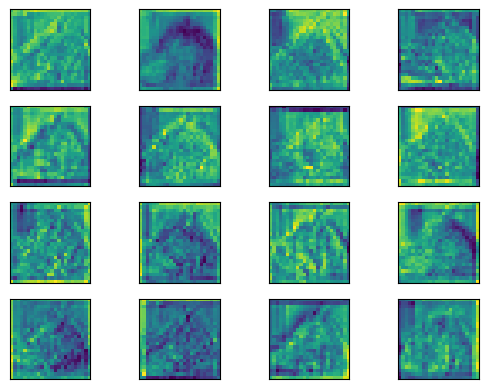

<Figure size 1200x800 with 0 Axes>

In [29]:
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize = (12, 8))
fig.subplots_adjust(left = 0, right =1, bottom = 0, top =1, hspace = 0.05, wspace = 0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row * 10 + column])
plt.show()

**40번째 계층에 대한 특성 맵**

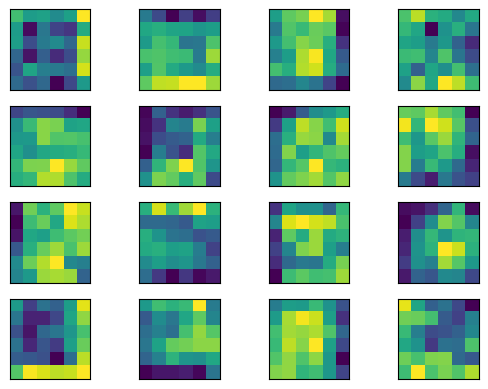

<Figure size 1200x800 with 0 Axes>

In [30]:
result = LayerActivations(model.features, 40)
model(img)
activations = result.features

fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize = (12, 8))
fig.subplots_adjust(left = 0, right =1, bottom = 0, top =1, hspace = 0.05, wspace = 0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row * 10 + column])
plt.show()